In [1]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std
import scipy.stats
import pickle

In [2]:
def cleanup(data):
    """
    Clean up CSV file output from Prolific experiment. 
    """
    fields = data.strip().split(',')
    fields = [field.strip('"').replace('\\', '').replace('{', '').replace('}', '').replace("'", '').replace("[", '').replace("]", '').replace('"', '') for field in fields]
    return fields

In [3]:
def parseCSV(filepath):
    """
    Parse rawdata CSV file saved from Prolific experiment. 
    """
    processed_data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for i,subj_data in enumerate(file):

            if i==0: continue # CSV headers

            processed_subj = cleanup(subj_data)

            subject_info = {
                'timestamp': processed_subj[4]
                }

            img_responses = []
            post_survey = {}
            resp = None
            images = ""

            for item in processed_subj[5:]:
                if ':' in item:
                    key, value = item.split(':', 1)

                    if key == 'response':
                        resp = value
                    elif 'image' in value:
                        imagename = os.path.basename(value).split(".")[0]
                        images += os.path.basename(imagename)
                    elif 'trial' in key:
                        subject_info[images] = resp
                        images = ""
                    else:
                        post_survey[key] = value

                # If subjects include newline character in post-survey comments
                else:
                    value = item
                    if resp and resp in post_survey:
                        post_survey[last_key] += ' ' + value

            subject_info.update(post_survey)
            processed_data.append(subject_info)

        # Create a DataFrame
        df = pd.DataFrame(processed_data)
        return df

In [4]:
def filter_subjects(df, attentioncheck):
    """
    Filter out subjects from the DataFrame based on the attention check. 
    Also filters out test runs of the experiment (labeled 'TEST' in post-survey comments). 
    If attentioncheck is true, filter based on attention check; otherwise, just remove test runs. 
    """

    df['students'] = pd.to_numeric(df['students'], errors='coerce')
    df['flashcards'] = pd.to_numeric(df['flashcards'], errors='coerce')
    if attentioncheck:
        filtered_df = df[(df['students'] == 1) & (~df['comments'].str.contains("TEST", na=False))]
    else:
        filtered_df = df[(~df['comments'].str.contains("TEST", na=False))]
    return filtered_df

In [5]:
filepath = 'computers_expt.csv'
df = parseCSV(filepath)
filtered_df = filter_subjects(df, attentioncheck=True)
filtered_df

,timestamp,,1agents1computer100flashcards,4agents6computers1flashcards,6agents2computers100flashcards,6agents6computers1flashcards,6agents2computers10flashcards,2agents2computers100flashcards,6agents6computers100flashcards,4agents2computers10flashcards,...,flashcards,language,enjoyment,assess,age,gender_cat,gender_text,education,comments,Looked at images of computers and how many vocabulary words were needed
0,1739559607171,5,None,10,3,10,5,1,1,5,...,100,English,better,y,32,f,,college,low number of flash cards = more acceptable to...,NaN
1,1739559130458,1,None,2,9,3,9,1,1,7,...,100,English,better,y,35,m,,NaN,None,NaN
2,1739559767675,5,None,9,7,9,5,2,7,5,...,100,English,average,y,39,m,,college,N/A,NaN
3,1739559909533,1,None,1,1,1,1,1,1,1,...,100,English,average,confused,41,f,,some-college,I was thinking no matter how many computers th...,NaN
4,1739559970317,3,None,3,4,5,4,1,1,3,...,100,English,average,y,45,f,,college,I graded more harshly for non-participation wh...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1739559331910,9,None,10,10,10,9,1,1,9,...,100,English,average,y,22,f,,college,I assessed the availability of the computers,NaN
296,1739558483870,3,None,1,3,1,4,1,1,1,...,100,English,average,y,32,f,,grad,NO,NaN
298,1739562402995,7,None,1,10,10,8,1,1,10,...,100,English,average,y,31,m,,college,,NaN
299,1739555004299,1,None,4,4,5,4,1,1,6,...,100,English,average,y,30,m,,high,No,NaN


In [6]:
import pandas as pd
import statsmodels.formula.api as smf
import json

def effect_code_workload(image_name):
    num_flashcards = image_name.split('computers')[1].split('flashcards')[0]
    if num_flashcards == '1':
        return [1, 0]
    elif num_flashcards == '10':
        return [0, 0]
    elif num_flashcards == '100':
        return [0, 1]
    else:
        return [None, None]

def effect_code_groupsize(image_name):
    num_students = image_name.split('agents')[0]
    if num_students == '2':
        return [1, 0]
    elif num_students == '4':
        return [0, 0]
    elif num_students == '6':
        return [0, 1]
    else:
        return [None, None]

def effect_code_bottlenecks(image_name):
    num_computers = image_name.split('computers')[0].split('agents')[1]
    if num_computers == '2':
        return 0
    elif num_computers == '6':
        return 1
    else:
        return [None, None]

In [7]:
image_columns = [col for col in filtered_df.columns if col.endswith('flashcards') and 'agents' in col and not col=='1agents1computer100flashcards']

long_df = pd.melt(filtered_df,id_vars=['timestamp'],value_vars=image_columns,var_name='image_type', value_name='response')
long_df[['x_1_1', 'x_1_2']] = pd.DataFrame(long_df['image_type'].apply(effect_code_workload).tolist(), index=long_df.index)
long_df[['x_2_1', 'x_2_2']] = pd.DataFrame(long_df['image_type'].apply(effect_code_groupsize).tolist(), index=long_df.index)
long_df[['x_3']] = pd.DataFrame(long_df['image_type'].apply(effect_code_bottlenecks).tolist(), index=long_df.index)

long_df = long_df.dropna(subset=['x_1_1', 'x_1_2', 'x_2_1', 'x_2_2', 'x_3'])
long_df['response'] = pd.to_numeric(long_df['response'], errors='coerce')
long_df = long_df.dropna(subset=['response'])

# model = smf.mixedlm(
#     "response ~ (x_1_1 + x_1_2 + x_2_1 + x_2_2 + x_3)",
#     long_df,
#     groups=long_df["timestamp"]
# )
model = smf.mixedlm(
    "response ~ (x_1_1 + x_1_2 + x_2_1 + x_2_2 + x_3 + "
    "x_1_1:x_2_1 + x_1_1:x_2_2 + x_1_1:x_3 + "
    "x_1_2:x_2_1 + x_1_2:x_2_2 + x_1_2:x_3 + "
    "x_2_1:x_3 + x_2_2:x_3)",
    long_df,
    groups=long_df["timestamp"]
)
result = model.fit()

print(result.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: response   
No. Observations: 5073    Method:             REML       
No. Groups:       283     Scale:              5.2512     
Min. group size:  13      Log-Likelihood:     -11732.2473
Max. group size:  18      Converged:          Yes        
Mean group size:  17.9                                   
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      5.116    0.152  33.643 0.000  4.818  5.414
x_1_1          2.272    0.157  14.435 0.000  1.963  2.580
x_1_2         -1.159    0.158  -7.357 0.000 -1.468 -0.850
x_2_1         -2.413    0.157 -15.330 0.000 -2.722 -2.105
x_2_2          0.715    0.158   4.530 0.000  0.405  1.024
x_3           -1.451    0.144 -10.089 0.000 -1.733 -1.169
x_1_1:x_2_1    0.799    0.193   4.144 0.000  0.421  1.177
x_1_1:x_2_2   -0.511    

/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_84366/1522862135.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset.groupby('group_size')['response'].mean()
/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_84366/1522862135.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sems = subset.groupby('group_size')['response'].apply(standard_error)


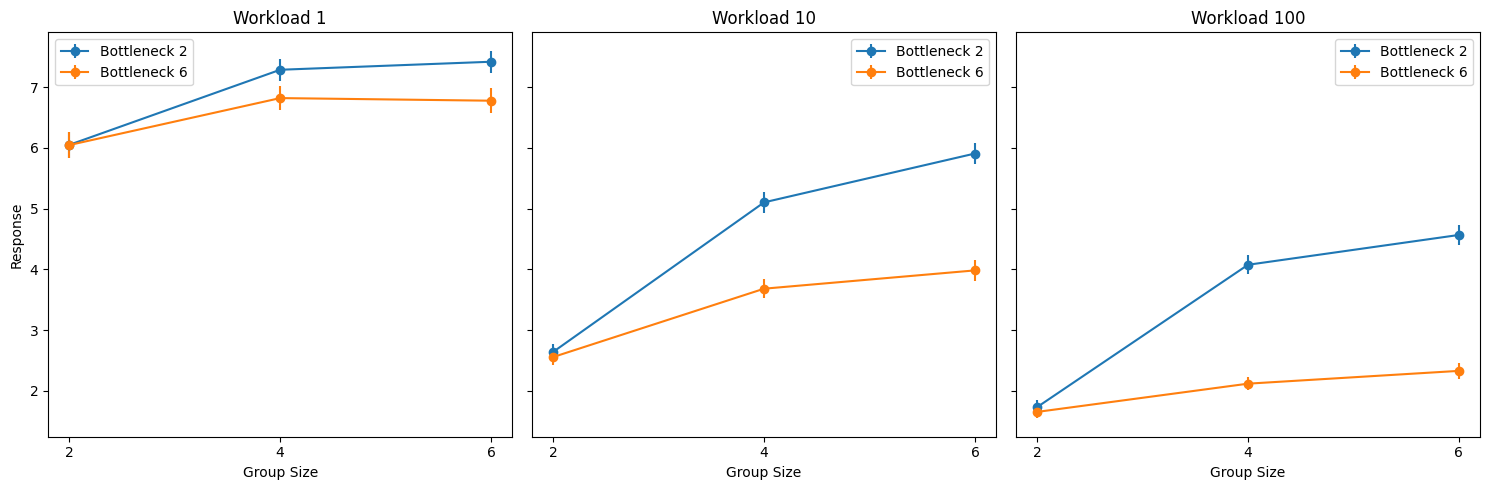

In [8]:
def decode_categories(row):
    if row['x_1_1'] == 1 and row['x_1_2'] == 0:
        row['workload'] = '1'
    elif row['x_1_1'] == 0 and row['x_1_2'] == 1:
        row['workload'] = '100'
    elif row['x_1_1'] == 0 and row['x_1_2'] == 0:
        row['workload'] = '10'

    row['bottleneck'] = '2' if row['x_3'] == 0 else '6'

    if row['x_2_1'] == 1 and row['x_2_2'] == 0:
        row['group_size'] = '2'
    elif row['x_2_1'] == 0 and row['x_2_2'] == 1:
        row['group_size'] = '6'
    elif row['x_2_1'] == 0 and row['x_2_2'] == 0:
        row['group_size'] = '4'

    return row

groupcoding = [
    (long_df['x_2_1'] == 1) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 1) 
]

workloadcoding = [
    (long_df['x_1_1'] == 1) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 1) 
]

bottleneckcoding = [
    (long_df['x_3'] == 0),
    (long_df['x_3'] == 1)
]

long_df['GroupSize'] = np.select(groupcoding, [2,4,6], default=np.nan)
long_df['Workload'] = np.select(workloadcoding, [1,10,100], default=np.nan)
long_df['Bottleneck'] = np.select(bottleneckcoding, [1,6], default=np.nan)

long_df = long_df.apply(decode_categories, axis=1)
long_df['group_size'] = pd.Categorical(long_df['group_size'], categories=['2', '4', '6'], ordered=True)
long_df['workload'] = pd.Categorical(long_df['workload'], categories=['1', '10', '100'], ordered=True)

def standard_error(data):
    return scipy.stats.sem(data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

workloads = ['1', '10', '100']

for i, (workload, ax) in enumerate(zip(workloads, axes.flatten())):
    for bottleneck in ['2','6']:
        subset = long_df[(long_df['workload'] == workload) & (long_df['bottleneck'] == bottleneck)]
        means = subset.groupby('group_size')['response'].mean()
        sems = subset.groupby('group_size')['response'].apply(standard_error)
        ax.errorbar(means.index, means, yerr=sems, label=f'Bottleneck {bottleneck}', fmt='-o')

    ax.set_title(f'Workload {workload}')
    ax.set_xlabel('Group Size')
    ax.legend()

axes[0].set_ylabel('Response')
plt.tight_layout()
plt.savefig("experiment4_bottlenecks.pdf")

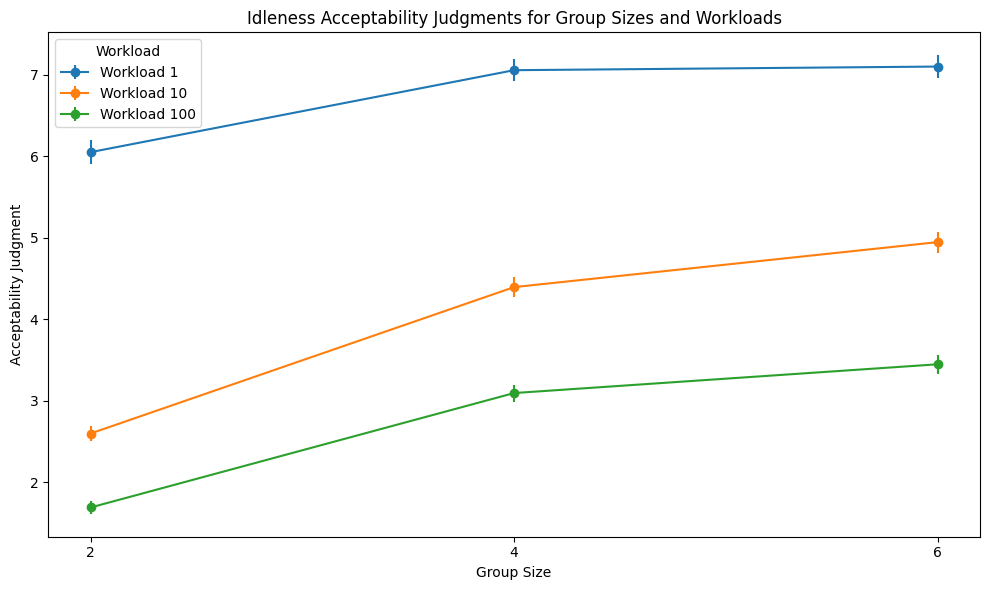

In [9]:
def standard_error(data):
    return scipy.stats.sem(data)

groupcoding = [
    (long_df['x_2_1'] == 1) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 1) 
]

workloadcoding = [
    (long_df['x_1_1'] == 1) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 1) 
]

long_df['GroupSize'] = np.select(groupcoding, [2,4,6], default=np.nan)
long_df['Workload'] = np.select(workloadcoding, [1,10,100], default=np.nan)

low_workload_data = long_df[long_df['x_1_1'] == 1]
med_workload_data = long_df[(long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 0)]
high_workload_data = long_df[long_df['x_1_2'] == 1]

plt.figure(figsize=(10, 6))

for data, label in zip([low_workload_data, med_workload_data, high_workload_data], ['Workload 1', 'Workload 10', 'Workload 100']):
    means = data.groupby('GroupSize')['response'].mean()
    sems = data.groupby('GroupSize')['response'].apply(standard_error)
    plt.errorbar(means.index, means, yerr=sems, label=label, fmt='-o')  

plt.xlabel('Group Size')
plt.ylabel('Acceptability Judgment')
plt.title('Idleness Acceptability Judgments for Group Sizes and Workloads')
plt.legend(title='Workload')
plt.xticks([2,4,6])
plt.tight_layout()
plt.savefig("expt4_workloadgs.pdf")

In [10]:
def getSubjectStats(df):
    gender_counts = df['gender_cat'].value_counts()
    print(gender_counts)
    
    mean_age = pd.to_numeric(df['age'].replace('', float('nan')), errors='coerce').mean()
    print("Mean Age:", mean_age)

    sd_age = pd.to_numeric(df['age'].replace('', float('nan')), errors='coerce').std()
    print("SD Age:", sd_age)

alldata_df = filter_subjects(df, attentioncheck=True)
getSubjectStats(alldata_df)

gender_cat
f     154
m     121
nb      4
Name: count, dtype: int64
Mean Age: 38.90681003584229
SD Age: 12.711742866106112


In [11]:
long_df.to_pickle('expt4_df.pkl')

In [12]:
long_df

,timestamp,image_type,response,x_1_1,x_1_2,x_2_1,x_2_2,x_3,GroupSize,Workload,Bottleneck,workload,bottleneck,group_size
0,1739559607171,4agents6computers1flashcards,10.0,1,0,0,0,1,4.0,1.0,6.0,1,6,4
1,1739559130458,4agents6computers1flashcards,2.0,1,0,0,0,1,4.0,1.0,6.0,1,6,4
2,1739559767675,4agents6computers1flashcards,9.0,1,0,0,0,1,4.0,1.0,6.0,1,6,4
3,1739559909533,4agents6computers1flashcards,1.0,1,0,0,0,1,4.0,1.0,6.0,1,6,4
4,1739559970317,4agents6computers1flashcards,3.0,1,0,0,0,1,4.0,1.0,6.0,1,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,1739559331910,4agents6computers10flashcards,4.0,0,0,0,0,1,4.0,10.0,6.0,10,6,4
5090,1739558483870,4agents6computers10flashcards,1.0,0,0,0,0,1,4.0,10.0,6.0,10,6,4
5091,1739562402995,4agents6computers10flashcards,6.0,0,0,0,0,1,4.0,10.0,6.0,10,6,4
5092,1739555004299,4agents6computers10flashcards,2.0,0,0,0,0,1,4.0,10.0,6.0,10,6,4
